In [1]:
# Import Basic Packgaes 
import numpy as np
import pandas as pd
from datetime import datetime
import statsmodels as sm
import itertools
import glob
import os
from scipy.signal import argrelextrema

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns # advanced vizs
from pandas.plotting import lag_plot

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Set Color Palettes
palette1 = itertools.cycle(sns.color_palette(palette='Set1'))
palette2 = itertools.cycle(sns.color_palette(palette='Set2'))


In [2]:
os.chdir("D:\\6.Pump_1_Right12'oclock crak left good_FFT\\Cleaned Data_FFT_DF_Shannon")

In [3]:
os.getcwd()

"D:\\6.Pump_1_Right12'oclock crak left good_FFT\\Cleaned Data_FFT_DF_Shannon"

In [4]:
# current directory csv files
csvs = [x for x in os.listdir("D:\\6.Pump_1_Right12'oclock crak left good_FFT\\Cleaned Data_FFT_DF_Shannon") if x.endswith('.csv')]
# stats.csv -> stats
fns = [os.path.splitext(os.path.basename(x))[0] for x in csvs]

dic_csv = {}
for i in range(len(fns)):
    dic_csv[fns[i]] = pd.read_csv(csvs[i])

In [5]:
dic_csv.keys()

dict_keys(['01.P3_14Oct23_shannon_val', '02.P3_15Oct23_shannon_val', '03.P3_16Oct23_shannon_val', '04.P3_17Oct23_shannon_val', '05.P3_18Oct23_shannon_val', '06.P3_19Oct23_shannon_val', '07.P3_20Oct23_shannon_val', '08.P3_21Oct23_shannon_val', '09.P3_22Oct23_shannon_val', '10.P3_23Oct23_shannon_val', '11.P3_24Oct23_shannon_val', '12.P3_25Oct23_shannon_val', '13.P3_26Oct23_shannon_val', '14.P3_27Oct23_shannon_val', '15.P3_28Oct23_shannon_val', '16.P3_29Oct23_shannon_val', '18.P3_31Oct23_shannon_val', '19.P3_01Nov23_shannon_val', '20.P3_02Nov23_shannon_val', '21.P3_03Nov23_shannon_val', '22.P3_06Nov23_shannon_val', '23.P3_07Nov23_shannon_val'])

In [6]:
dic_csv['01.P3_14Oct23_shannon_val'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  15 non-null     int64  
 1   Entropy     15 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 368.0 bytes


In [11]:
dic_csv['01.P3_14Oct23_shannon_val'].head()

,Entropy
0,7.74
1,7.85
2,7.87
3,7.50
4,7.57


In [8]:
for key, df in dic_csv.items():
    df.drop(columns=['Unnamed: 0' ], axis=1, inplace=True)

In [10]:
for key, df in dic_csv.items():
    df['Entropy'] = np.round(df['Entropy'], decimals=2)

In [9]:
#for key, df in dic_csv.items():
    #df.sort_values(by=['Entropy'])

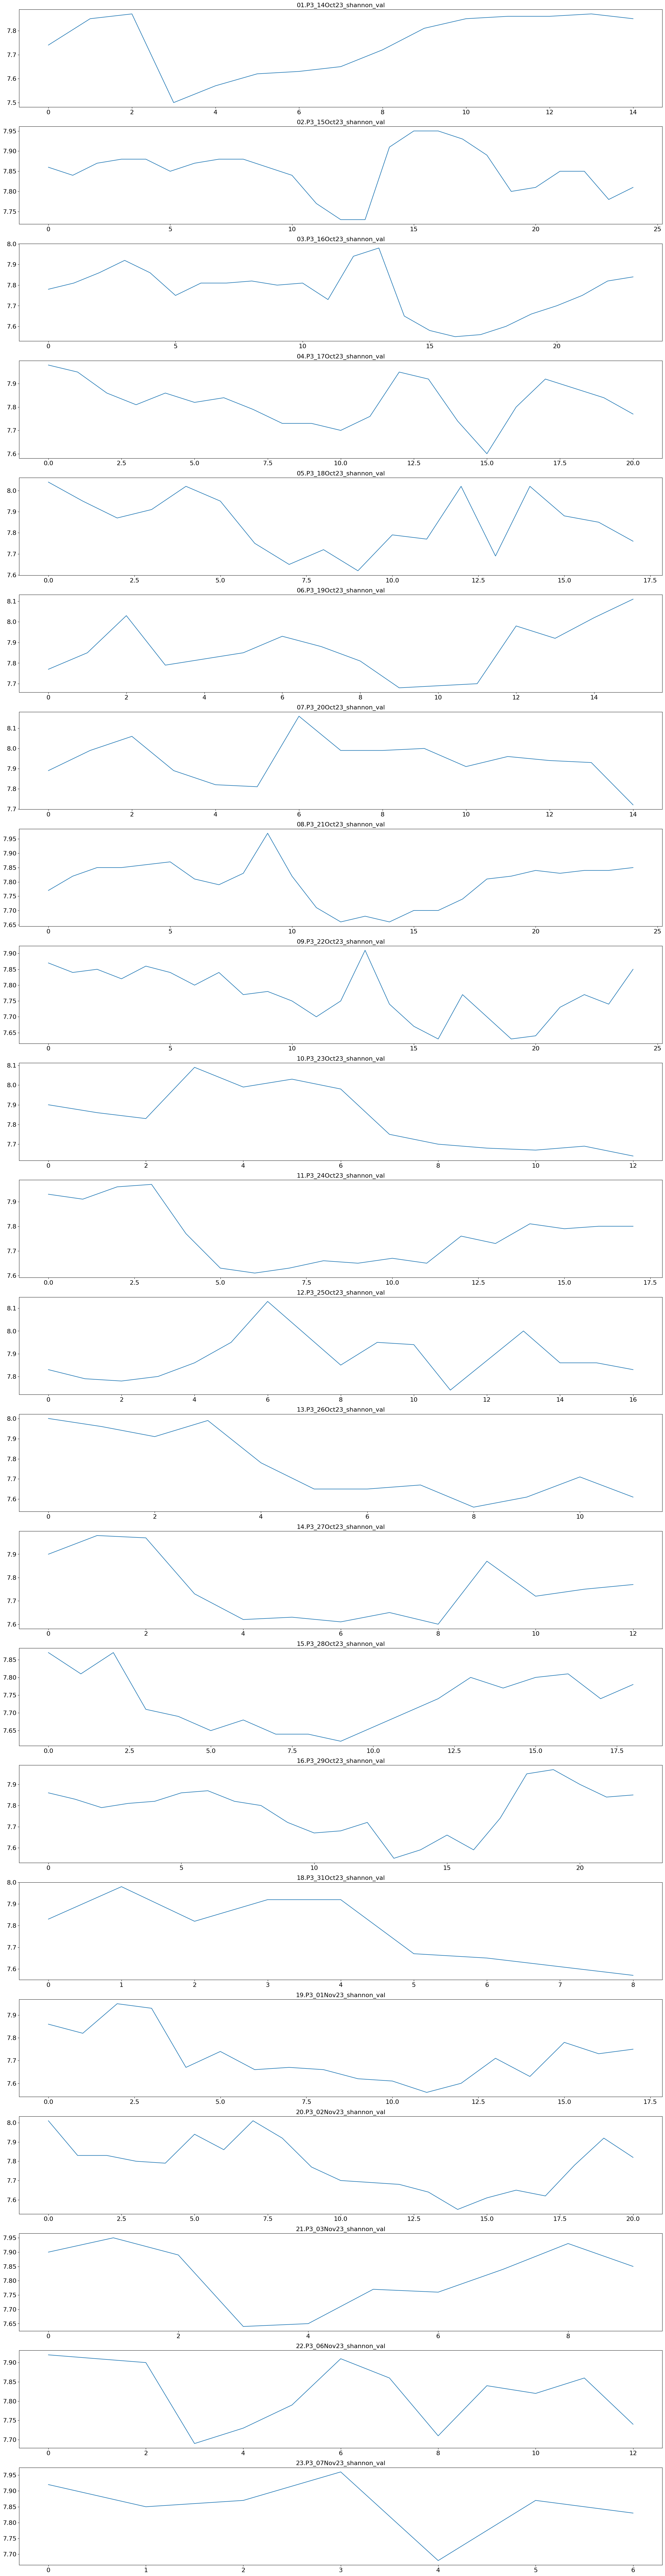

In [14]:
a = len(dic_csv)  # number of rows
b = 1  # number of columns
c = 1  # initialize plot counter

fig1 = plt.figure(figsize=(30,120))

SMALL_SIZE = 16

for j,i in dic_csv.items():
    plt.subplot(a, b, c)
    plt.plot(i.index, i['Entropy'])
    #plt.ylim(0,80000)
    #plt.xticks(np.arange(min(i.index), max(i.index), 1))
    plt.title(j)
    c = c + 1

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.show()

In [16]:
timeline = [n for n in np.arange(0,352,16)]

In [17]:
amp_max = []

In [27]:
amp_min = []

In [19]:
for key, df in dic_csv.items():
    amp_max.append(np.max(df['Entropy']))

In [28]:
for key, df in dic_csv.items():
    amp_min.append(np.min(df['Entropy']))

In [20]:
print(timeline)

[0, 16, 32, 48, 64, 80, 96, 112, 128, 144, 160, 176, 192, 208, 224, 240, 256, 272, 288, 304, 320, 336]


In [24]:
# Create a DataFrame for the current fr,amp
fr_3Hz_df = pd.DataFrame({'Life Hrs': timeline,'Entro': amp_max})


In [29]:
# Create a DataFrame for the current fr,amp
Entro_df = pd.DataFrame({'Life Hrs': timeline,'Entro': amp_min})

In [22]:
fr_3Hz_df.head(1000)

,Entro
0,7.87
1,7.95
2,7.98
3,7.98
4,8.04
5,8.11
6,8.16
7,7.97
8,7.91
9,8.09


Text(0.5, 1.0, 'Diapragm lifetime vs Shannon Entropy')

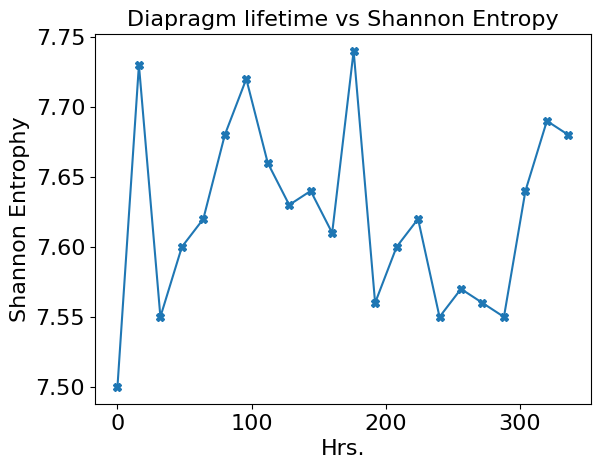

In [30]:
plt.plot(timeline,amp_min, marker ='X')
plt.xlabel('Hrs.')
plt.ylabel('Shannon Entrophy')
plt.title('Diapragm lifetime vs Shannon Entropy')

Text(0.5, 1.0, 'Diapragm lifetime vs Shannon Entropy')

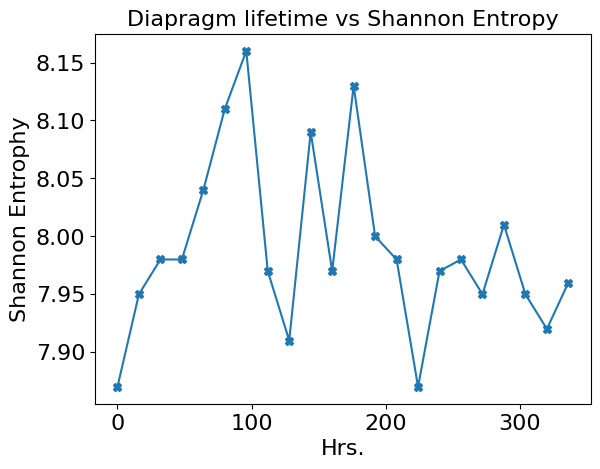

In [26]:
plt.plot(timeline,amp_max, marker ='X')
plt.xlabel('Hrs.')
plt.ylabel('Shannon Entrophy')
plt.title('Diapragm lifetime vs Shannon Entropy')